<a href="https://colab.research.google.com/github/jiminmini/mini/blob/ESAA_OB_%EC%84%B8%EC%85%98(%EA%B8%88)/09_12_%EC%84%B8%EC%85%98_%EB%AA%A8%EB%8D%B8%ED%9B%88%EB%A0%A8_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **모델 훈련 연습 문제**
___
- 출처 : 핸즈온 머신러닝 Ch04 연습문제 1, 5, 9, 10
- 개념 문제의 경우 텍스트 셀을 추가하여 정답을 적어주세요.

### **1. 수백만 개의 특성을 가진 훈련 세트에서는 어떤 선형 회귀 알고리즘을 사용할 수 있을까요?**
___


- 확률적 경사 하강법 기반의 선형 회귀 알고리즘

### **2. 배치 경사 하강법을 사용하고 에포크마다 검증 오차를 그래프로 나타내봤습니다. 검증 오차가 일정하게 상승되고 있다면 어떤 일이 일어나고 있는 걸까요? 이 문제를 어떻게 해결할 수 있나요?**
___

1. 문제: 과적합(훈련손실은 내려가고 검증 손실은 올라갈때)

   해결방법: 정규화 추가, 모델 용량 축소, 데이터 늘리기, 조기 종료

2. 문제: 학습 불안정/발산

    해결 방법: 학습률 낮추기, 다른 옵티마이저 시도

### **3. 릿지 회귀를 사용했을 때 훈련 오차가 검증 오차가 거의 비슷하고 둘 다 높았습니다. 이 모델에는 높은 편향이 문제인가요, 아니면 높은 분산이 문제인가요? 규제 하이퍼파라미터 $\alpha$를 증가시켜야 할까요 아니면 줄여야 할까요?**
___

- 상황: 과소적합 상황
- 두 오차가 모두 높으므로 편향 문제이다.
- 규제 하이퍼파라미터 α를 줄여야 한다.(α 감소-> 규제 약해짐 -> 편향 감소, 분산 증가)

### **4. 다음과 같이 사용해야 하는 이유는?**
___
- 평범한 선형 회귀(즉, 아무런 규제가 없는 모델) 대신 릿지 회귀
- 릿지 회귀 대신 라쏘 회귀
- 라쏘 회귀 대신 엘라스틱넷

1. 과적합 방지와 계수 안정화를 위함이다.

2. 불필요한 특성이 많을 때 모델 해석력 향상을 위해 라쏘를 사용한다.

3. 상관관계가 높은 변수들이 많거나 특성> 샘플 상황에서는 엘라스틱넷이 더 적합하다.

### **추가) 조기 종료를 사용한 배치 경사 하강법으로 iris 데이터를 활용해 소프트맥스 회귀를 구현해보세요(사이킷런은 사용하지 마세요)**


---



In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# 1. 데이터 준비
iris = load_iris()
X = iris.data
y = iris.target

In [3]:
# one-hot 인코딩
num_classes = len(np.unique(y))
y_onehot = np.eye(num_classes)[y]

In [4]:
# train/test 분리
X_train, X_val, y_train, y_val = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

In [5]:
# 표준화
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - X_mean) / X_std
X_val = (X_val - X_mean) / X_std

In [6]:
# 2. 소프트맥스 함수 & 손실
def softmax(logits):
    exp = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    eps = 1e-15
    return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))

In [7]:
# 3. 모델 학습 함수
def train_softmax(X_train, y_train, X_val, y_val, lr=0.1, epochs=1000, patience=20):
    n_samples, n_features = X_train.shape
    n_classes = y_train.shape[1]

    # 가중치 초기화
    W = np.zeros((n_features, n_classes))
    b = np.zeros((1, n_classes))

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    wait = 0

    for epoch in range(epochs):
        # forward
        logits = X_train.dot(W) + b
        y_pred = softmax(logits)
        loss = cross_entropy(y_train, y_pred)

        # backward
        grad_W = X_train.T.dot(y_pred - y_train) / n_samples
        grad_b = np.mean(y_pred - y_train, axis=0, keepdims=True)

        # parameter update
        W -= lr * grad_W
        b -= lr * grad_b

        # validation loss
        val_logits = X_val.dot(W) + b
        y_val_pred = softmax(val_logits)
        val_loss = cross_entropy(y_val, y_val_pred)

        train_losses.append(loss)
        val_losses.append(val_loss)

        # early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_W, best_b = W.copy(), b.copy()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    return best_W, best_b, train_losses, val_losses

In [8]:
# 4. 실행
W, b, train_losses, val_losses = train_softmax(X_train, y_train, X_val, y_val, lr=0.1, epochs=1000)

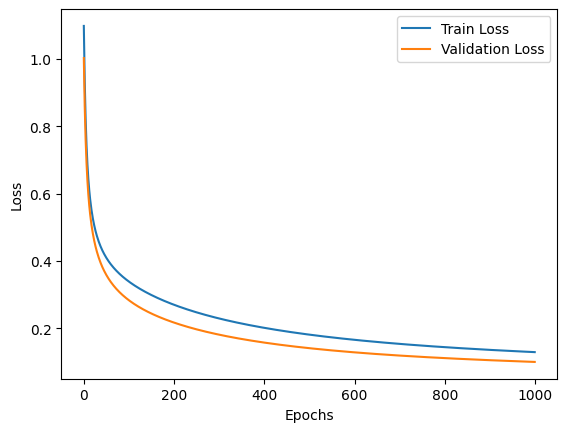

In [9]:
# 5. 학습 곡선 시각화
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [10]:
# 6. 최종 정확도 확인
def accuracy(X, y, W, b):
    logits = X.dot(W) + b
    preds = np.argmax(softmax(logits), axis=1)
    true = np.argmax(y, axis=1)
    return np.mean(preds == true)

print("Train Accuracy:", accuracy(X_train, y_train, W, b))
print("Validation Accuracy:", accuracy(X_val, y_val, W, b))

Train Accuracy: 0.9666666666666667
Validation Accuracy: 1.0
